## Computing and Research Methods for Climate Data Science Final Project

### Louis Durance ld3228 - "How have crop type distributions across Saskatchewan evolved from 2009 to 2023, and is there evidence of a spatial and temporal shift from wheat toward canola, consistent with economic incentives and changing climate conditions in the Canadian Prairies?"

### Introduction

In [ ]:
This project investigates how crop type distributions across Saskatchewan have evolved between 2009 and 2023, with a focus on whether a spatial and temporal shift from wheat toward canola is detectable, consistent with documented economic incentives (higher canola profit margins) and changing climate conditions in the Canadian Prairies.

The dataset used is the **Canada AAFC Annual Crop Inventory (AAFC/ACI)**, a satellite-derived land cover product produced by Agriculture and Agri-Food Canada at 30m resolution, available through Google Earth Engine. The study area is clipped to the agricultural extent of Saskatchewan (approximately 49°N–55°N, 101.5°W–110°W).

The analysis proceeds in three steps:
1. Extracting annual pixel counts by crop class from GEE and converting them to area estimates (hectares)
2. Computing land-use shares and the canola-to-wheat ratio over time as a proxy for economic and climate-driven shifts
3. Producing spatial maps and summary visualizations to identify temporal and geographic patterns

#### Step 1: Python Libraries

In [1]:
# Install required packages (run this cell first, then restart the kernel)
import sys
!{sys.executable} -m pip install earthengine-api geemap cartopy

Defaulting to user installation because normal site-packages is not writeable


In [ ]:
# Google Earth Engine API and geemap for spatial data access
import ee
import geemap

# Data manipulation
import pandas as pd
import numpy as np

# Plotting
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

# Mapping
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Utilities
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

#### Step 2: Authenticate and Initialize Google Earth Engine

In [2]:
# Step 2a — Import and install
import sys
!{sys.executable} -m pip install earthengine-api geemap --quiet

import ee

# Step 2b — Authenticate (follow the browser prompt)
ee.Authenticate()

Enter verification code:  4/1Aci98E9-lktNrfdPBnv1NiwjPmkkz5vYQFtu7-KH0wyf12i0dSbIwYvABJ4



Successfully saved authorization token.


In [6]:
ee.Initialize(project='computing-2-494319')
print("Google Earth Engine initialized successfully!")

Google Earth Engine initialized successfully!


#### Step 3: Study Area and Crop Class Definitions

In [7]:
# Define the Saskatchewan bounding box as a GEE geometry
# Coordinates: [west, south, east, north]
saskatchewan = ee.Geometry.Rectangle([-110.0, 49.0, -101.5, 55.0])

print('Study area defined: Saskatchewan bounding box')
print('Bounds: 49N-55N, 101.5W-110W')

Study area defined: Saskatchewan bounding box
Bounds: 49N-55N, 101.5W-110W


In [8]:
# The six crops of primary interest for this study
FOCUS_CROPS = {
    131: 'Spring Wheat',
    133: 'Durum Wheat',
    145: 'Canola',
    136: 'Barley',
    156: 'Lentils',
    122: 'Summerfallow',
}

# Color palette for plotting
CROP_COLORS = {
    'Spring Wheat':  '#f5c242',   # golden yellow
    'Durum Wheat':   '#e8a020',   # dark amber
    'Canola':        '#4caf1a',   # bright green
    'Barley':        '#a0785a',   # brown
    'Lentils':       '#e05c5c',   # red
    'Summerfallow':  '#c9b99a',   # tan/beige
}

print(f'Number of focus crop classes: {len(FOCUS_CROPS)}')
print('Focus crops:', list(FOCUS_CROPS.values()))

Number of focus crop classes: 6
Focus crops: ['Spring Wheat', 'Durum Wheat', 'Canola', 'Barley', 'Lentils', 'Summerfallow']


In [ ]:
### We define the study area as a bounding box covering Saskatchewan's main agricultural belt. The six focus crops — Spring Wheat, Durum Wheat, Canola, Barley, Lentils, and Summerfallow — were selected because they represent the dominant land uses in the Canadian Prairies and are the most relevant to the wheat-to-canola shift hypothesis.

#### Step 4: Data Extraction from Google Earth Engine

In [33]:
# Correct band name is 'landcover'
def extract_crop_histogram(year):
    image = (
        ee.ImageCollection('AAFC/ACI')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .first()
        .clip(saskatchewan)
    )

    histogram = image.reduceRegion(
        reducer=ee.Reducer.frequencyHistogram(),
        geometry=saskatchewan,
        scale=1000,
        maxPixels=1e10,
        bestEffort=True
    )

    # Correct band name is 'landcover'
    hist_dict = histogram.getInfo().get('landcover', {})
    return hist_dict


# Re-extract histograms for all years
years = list(range(2009, 2024))
raw_histograms = {}

for year in years:
    print(f'Extracting data for {year}...', end=' ')
    raw_histograms[year] = extract_crop_histogram(year)
    print('done')

print('\nSample 2020:', raw_histograms[2020])

Extracting data for 2009... done
Extracting data for 2010... done
Extracting data for 2011... done
Extracting data for 2012... done
Extracting data for 2013... done
Extracting data for 2014... done
Extracting data for 2015... done
Extracting data for 2016... done
Extracting data for 2017... done
Extracting data for 2018... done
Extracting data for 2019... done
Extracting data for 2020... done
Extracting data for 2021... done
Extracting data for 2022... done
Extracting data for 2023... done

Sample 2020: {'110': 39952.4745098039, '122': 38333.25882352941, '130': 56, '131': 2388.4588235294113, '133': 16985.368627450982, '135': 11, '136': 8410.580392156862, '137': 195.40392156862745, '138': 12, '139': 79, '142': 8, '143': 7, '145': 111.89411764705882, '146': 48245.14901960785, '147': 386.4470588235294, '152': 12, '153': 66758.33333333331, '154': 2281.949019607843, '155': 649.094117647059, '157': 24.419607843137257, '158': 436.4235294117648, '162': 9562.94901960784, '163': 799.039215686274

In [ ]:
### For each year from 2009 to 2023, we query the AAFC/ACI image collection on Google Earth Engine, clip it to the Saskatchewan bounding box, and compute a frequency histogram of pixel values at 1km scale. Each pixel value corresponds to a specific crop class code, and the pixel count is proportional to the area covered by that crop.

#### Step 5: Build the Crop Area DataFrame

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import ee
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported!")

Libraries imported!


In [35]:
# Build DataFrame
PIXEL_AREA_HA = 100  # hectares per pixel at 1000m scale

def parse_histogram(hist_dict, focus_crops):
    areas = {}
    for pixel_val, crop_name in focus_crops.items():
        count = hist_dict.get(str(pixel_val), 0)
        areas[crop_name] = count * PIXEL_AREA_HA
    return areas

rows = []
for year in years:
    row = {'Year': year}
    row.update(parse_histogram(raw_histograms[year], FOCUS_CROPS))
    rows.append(row)

df = pd.DataFrame(rows).set_index('Year')
df = df / 1e6  # convert to Million Hectares

print('Crop area DataFrame (Mha):')
print(df.round(3))

Crop area DataFrame (Mha):
      Spring Wheat  Durum Wheat  Canola  Barley  Lentils  Summerfallow
Year                                                                  
2009         1.069        0.584   0.077   0.197      0.0         4.843
2010         0.561        0.385   0.045   0.071      0.0         5.041
2011         0.353        0.275   0.000   0.188      0.0         4.943
2012         0.488        0.458   0.000   0.167      0.0         4.557
2013         0.513        0.551   0.025   0.355      0.0         4.905
2014         0.435        0.396   0.041   0.243      0.0         4.698
2015         0.334        0.491   0.041   0.360      0.0         4.030
2016         0.384        0.766   0.070   0.335      0.0         3.511
2017         0.233        0.629   0.066   0.381      0.0         3.366
2018         0.247        0.758   0.013   0.292      0.0         3.039
2019         0.078        1.961   0.020   0.678      0.0         3.783
2020         0.239        1.699   0.011   0.841   

In [36]:
# Compute shares and ratio
df['Total Focus Crops'] = df[list(FOCUS_CROPS.values())].sum(axis=1)
df_share = df[list(FOCUS_CROPS.values())].div(df['Total Focus Crops'], axis=0) * 100
df['Total Wheat'] = df['Spring Wheat'] + df['Durum Wheat']
df['Canola-to-Wheat Ratio'] = df['Canola'] / df['Total Wheat']

print('\nLand-use share (%) per year:')
print(df_share.round(2))

print('\nCanola-to-Wheat Ratio:')
print(df['Canola-to-Wheat Ratio'].round(3))


Land-use share (%) per year:
      Spring Wheat  Durum Wheat  Canola  Barley  Lentils  Summerfallow
Year                                                                  
2009         15.79         8.63    1.14    2.91      0.0         71.53
2010          9.20         6.30    0.74    1.17      0.0         82.59
2011          6.12         4.77    0.00    3.27      0.0         85.84
2012          8.61         8.08    0.00    2.95      0.0         80.36
2013          8.08         8.68    0.39    5.59      0.0         77.25
2014          7.48         6.81    0.70    4.18      0.0         80.83
2015          6.35         9.34    0.79    6.85      0.0         76.68
2016          7.58        15.11    1.39    6.62      0.0         69.30
2017          4.98        13.45    1.41    8.14      0.0         72.02
2018          5.69        17.43    0.29    6.71      0.0         69.87
2019          1.20        30.08    0.30   10.39      0.0         58.03
2020          3.61        25.65    0.17   12.70

In [ ]:
### The raw pixel counts are converted to area estimates in hectares (1 pixel at 1km scale ≈ 100 ha). We then organize the data into a Pandas DataFrame indexed by year, with one column per crop. From this, we compute each crop's share of the total focus-crop area and the canola-to-wheat ratio, which serves as the primary indicator of the hypothesized shift.

#### Step 6: Figure 1: Time Series of Major Crop Areas (2009–2023)

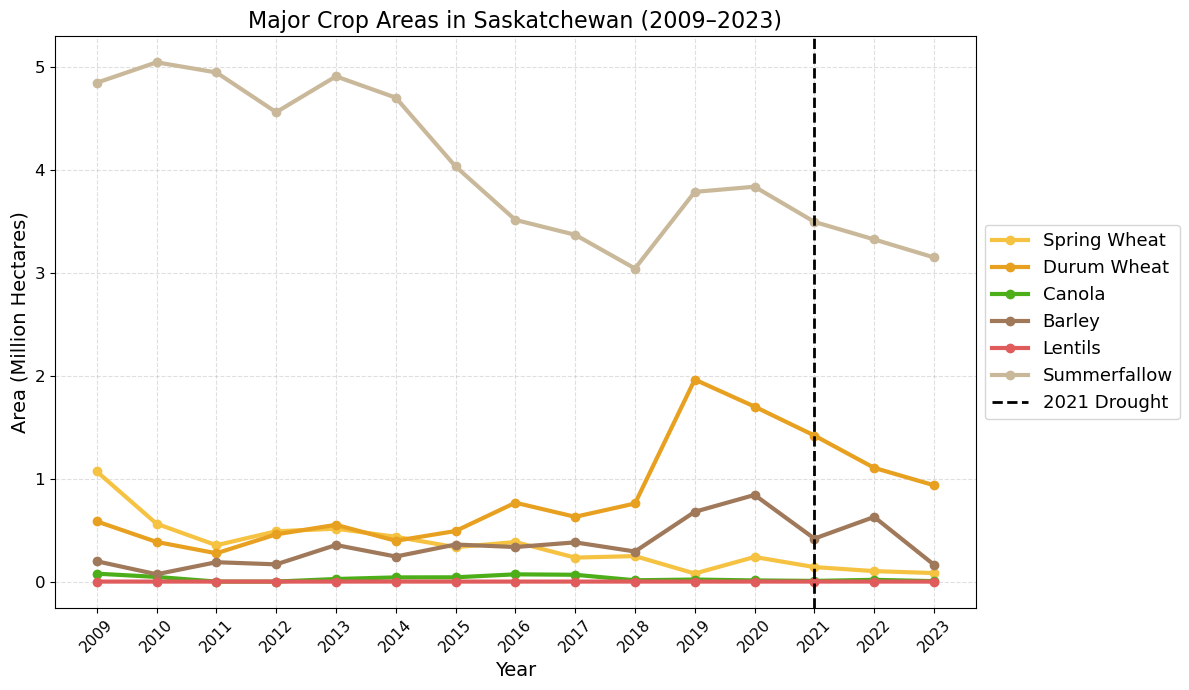

In [37]:
fig, ax = plt.subplots(figsize=(12, 7))

for crop in FOCUS_CROPS.values():
    ax.plot(
        df.index,
        df[crop],
        label=crop,
        color=CROP_COLORS[crop],
        linewidth=3,
        marker='o',
        markersize=6
    )

# Mark the 2021 Prairie drought with a vertical line
ax.axvline(x=2021, color='black', linestyle='--', linewidth=2, label='2021 Drought')

ax.set_title('Major Crop Areas in Saskatchewan (2009–2023)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Area (Million Hectares)', fontsize=14)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=11)
ax.tick_params(axis='y', labelsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
### This time series shows the absolute area (in millions of hectares) covered by each of the six focus crops annually. The 2021 drought year is marked, as it caused a significant reduction in crop area across the Prairies.

#### Step 7: Figure 2: Canola-to-Wheat Ratio Over Time

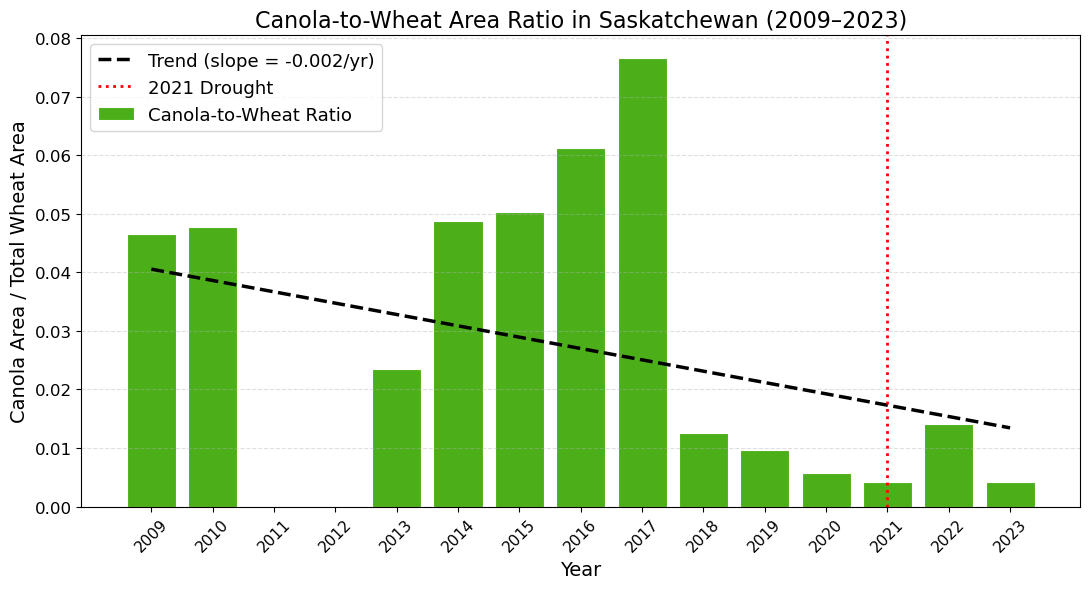

In [38]:
fig, ax = plt.subplots(figsize=(11, 6))

ax.bar(
    df.index,
    df['Canola-to-Wheat Ratio'],
    color='#4caf1a',
    edgecolor='white',
    linewidth=0.8,
    label='Canola-to-Wheat Ratio'
)

# Add a linear trend line
z = np.polyfit(df.index, df['Canola-to-Wheat Ratio'], 1)
p = np.poly1d(z)
ax.plot(df.index, p(df.index), color='black', linestyle='--',
        linewidth=2.5, label=f'Trend (slope = {z[0]:.3f}/yr)')

# Mark the 2021 Prairie drought
ax.axvline(x=2021, color='red', linestyle=':', linewidth=2, label='2021 Drought')

ax.set_title('Canola-to-Wheat Area Ratio in Saskatchewan (2009–2023)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Canola Area / Total Wheat Area', fontsize=14)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=11)
ax.tick_params(axis='y', labelsize=12)
ax.legend(fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
### The canola-to-wheat ratio captures the relative balance between canola and combined wheat (spring + durum). A rising trend would support the hypothesis that farmers are substituting canola for wheat over time, driven by higher profit margins and improved climate suitability at higher latitudes.

#### Step 8: Figure 3: Stacked Area Chart of Land-Use Shares

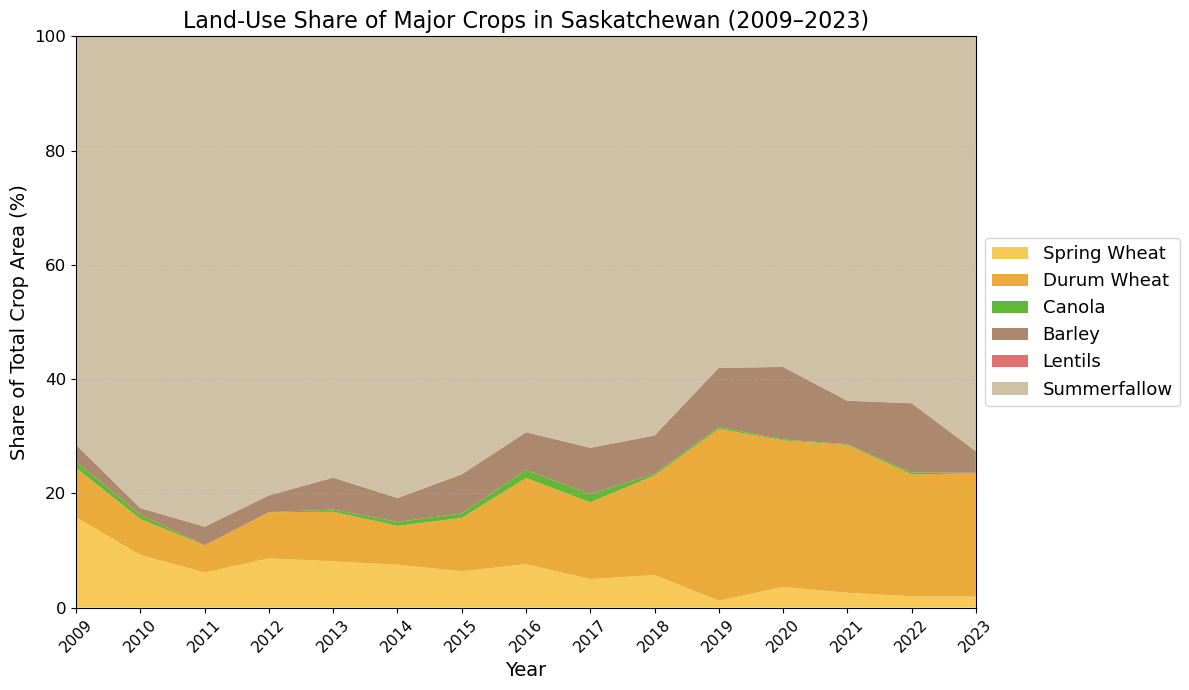

In [39]:
fig, ax = plt.subplots(figsize=(12, 7))

crop_list  = list(FOCUS_CROPS.values())
color_list = [CROP_COLORS[c] for c in crop_list]

ax.stackplot(
    df_share.index,
    [df_share[c] for c in crop_list],
    labels=crop_list,
    colors=color_list,
    alpha=0.88
)

ax.set_title('Land-Use Share of Major Crops in Saskatchewan (2009–2023)', fontsize=16)
ax.set_xlabel('Year', fontsize=14)
ax.set_ylabel('Share of Total Crop Area (%)', fontsize=14)
ax.set_xlim(2009, 2023)
ax.set_ylim(0, 100)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, fontsize=11)
ax.tick_params(axis='y', labelsize=12)
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=13)
ax.grid(True, linestyle='--', alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
### The stacked area chart provides a normalized view of how each crop's share of total agricultural land has evolved year-by-year, making it easier to compare relative changes across crops simultaneously.

#### Step 9: Figure 4: Spatial Maps of Dominant Crop Type (2009 vs. 2023)

In [40]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.patches as mpatches
import numpy as np

# Download pixel arrays for 2009 and 2023
def get_crop_array(year):
    image = (
        ee.ImageCollection('AAFC/ACI')
        .filterDate(f'{year}-01-01', f'{year}-12-31')
        .first()
        .clip(saskatchewan)
    )
    
    # Sample pixels across Saskatchewan
    samples = image.sample(
        region=saskatchewan,
        scale=5000,
        numPixels=5000,
        seed=42,
        geometries=True
    ).getInfo()
    
    return samples

print('Downloading 2009 data...')
samples_2009 = get_crop_array(2009)
print('Downloading 2023 data...')
samples_2023 = get_crop_array(2023)
print('Done!')

Done!


In [41]:
def samples_to_lists(samples, focus_crops):
    """Extract coordinates and crop class from GEE samples."""
    lons, lats, crop_indices = [], [], []
    crop_keys = list(focus_crops.keys())
    
    for feature in samples['features']:
        val = feature['properties'].get('landcover', -1)
        if val in crop_keys:
            coords = feature['geometry']['coordinates']
            lons.append(coords[0])
            lats.append(coords[1])
            crop_indices.append(crop_keys.index(val))
    
    return lons, lats, crop_indices

lons_2009, lats_2009, idx_2009 = samples_to_lists(samples_2009, FOCUS_CROPS)
lons_2023, lats_2023, idx_2023 = samples_to_lists(samples_2023, FOCUS_CROPS)

print(f'2009: {len(lons_2009)} points')
print(f'2023: {len(lons_2023)} points')

2009: 758 points
2023: 418 points


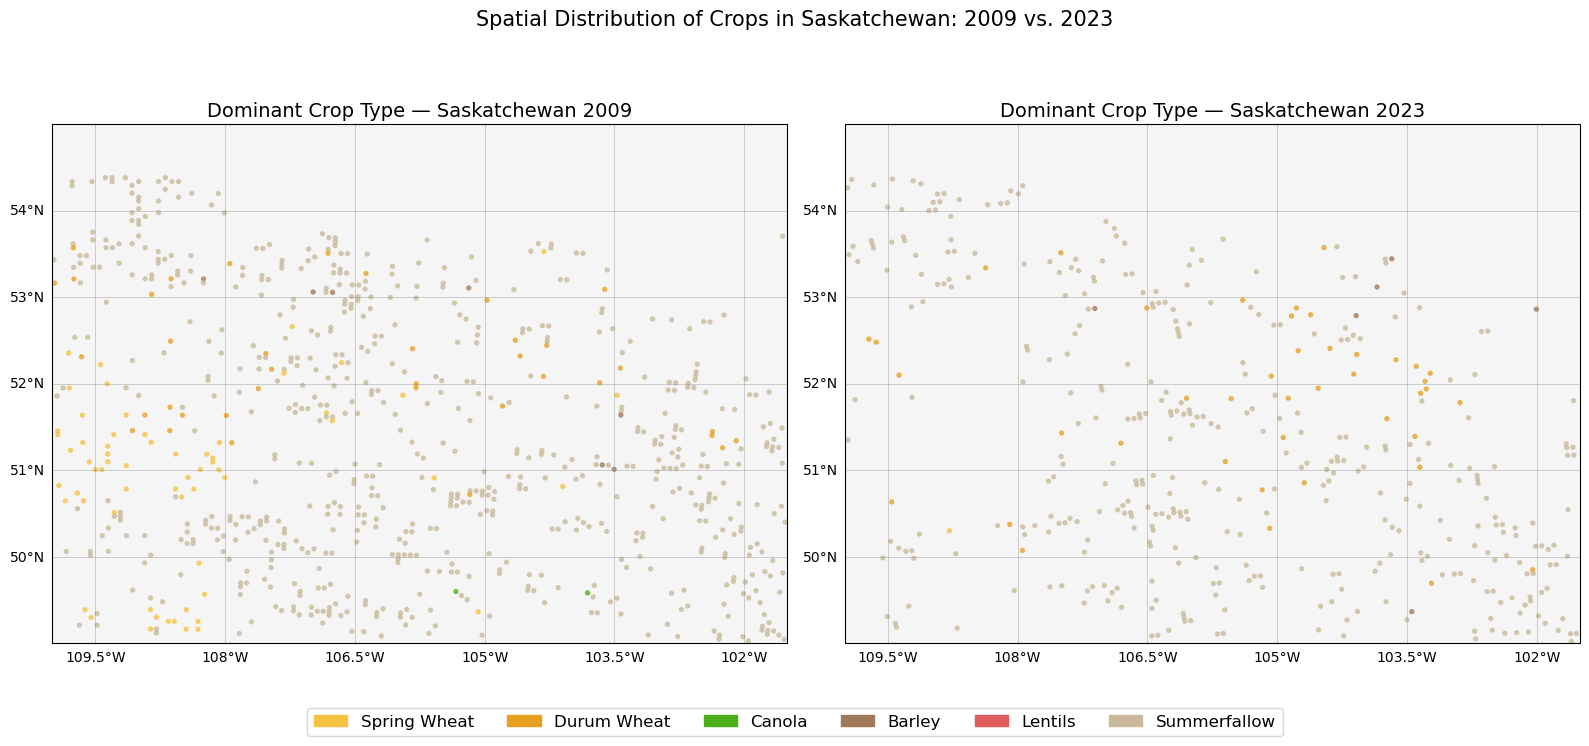

In [43]:
# Build colormap from CROP_COLORS
crop_names = list(FOCUS_CROPS.values())
color_list  = [CROP_COLORS[c] for c in crop_names]

fig, axes = plt.subplots(
    1, 2,
    figsize=(16, 7),
    subplot_kw={'projection': ccrs.PlateCarree()}
)

for ax, lons, lats, indices, year in zip(
    axes,
    [lons_2009, lons_2023],
    [lats_2009, lats_2023],
    [idx_2009,  idx_2023],
    [2009, 2023]
):
    colors_plot = [color_list[i] for i in indices]
    
    ax.set_extent([-110.0, -101.5, 49.0, 55.0], crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.BORDERS, linewidth=1.0)
    ax.add_feature(cfeature.LAND, facecolor='#f5f5f5')
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
    
    ax.scatter(lons, lats, c=colors_plot, s=8,
               transform=ccrs.PlateCarree(), alpha=0.7)
    
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5)
    gl.top_labels   = False
    gl.right_labels = False
    
    ax.set_title(f'Dominant Crop Type — Saskatchewan {year}', fontsize=14)

# Shared legend
legend_patches = [
    mpatches.Patch(color=CROP_COLORS[name], label=name)
    for name in crop_names
]
fig.legend(
    handles=legend_patches,
    loc='lower center',
    ncol=len(crop_names),
    fontsize=12,
    bbox_to_anchor=(0.5, -0.04)
)

plt.suptitle('Spatial Distribution of Crops in Saskatchewan: 2009 vs. 2023',
             fontsize=15, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
### The spatial scatter maps show where each crop was grown in 2009 and 2023, sampled at 5km resolution across Saskatchewan. Comparing the two years allows us to identify whether canola expanded northward or into areas previously dominated by wheat.

#### Step 10: Figure 5: Grouped Bar Chart: Crop Area Comparison 2009 vs 2023

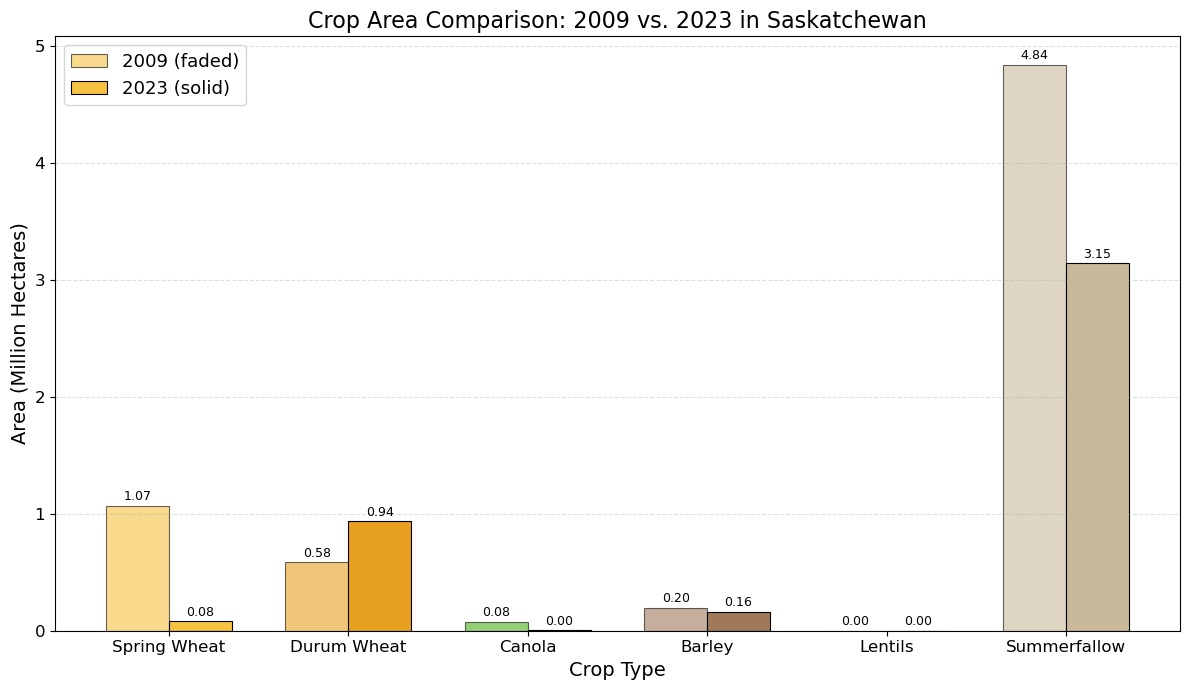

In [44]:
import numpy as np

crop_list = list(FOCUS_CROPS.values())
x = np.arange(len(crop_list))
width = 0.35

values_2009 = [df.loc[2009, crop] for crop in crop_list]
values_2023 = [df.loc[2023, crop] for crop in crop_list]

fig, ax = plt.subplots(figsize=(12, 7))

bars1 = ax.bar(x - width/2, values_2009, width, label='2009',
               color=[CROP_COLORS[c] for c in crop_list], alpha=0.6, edgecolor='black', linewidth=0.8)
bars2 = ax.bar(x + width/2, values_2023, width, label='2023',
               color=[CROP_COLORS[c] for c in crop_list], alpha=1.0, edgecolor='black', linewidth=0.8)

# Add value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)

ax.set_title('Crop Area Comparison: 2009 vs. 2023 in Saskatchewan', fontsize=16)
ax.set_xlabel('Crop Type', fontsize=14)
ax.set_ylabel('Area (Million Hectares)', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels(crop_list, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
ax.legend(['2009 (faded)', '2023 (solid)'], fontsize=13)
ax.grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

In [ ]:
### The grouped bar chart directly compares absolute crop areas between the first (2009) and last (2023) year of the study period, making year-over-year changes in each crop's total footprint immediately visible.

#### Step 11: Figure 6: Heatmap of Annual Crop Share (%) Over Time

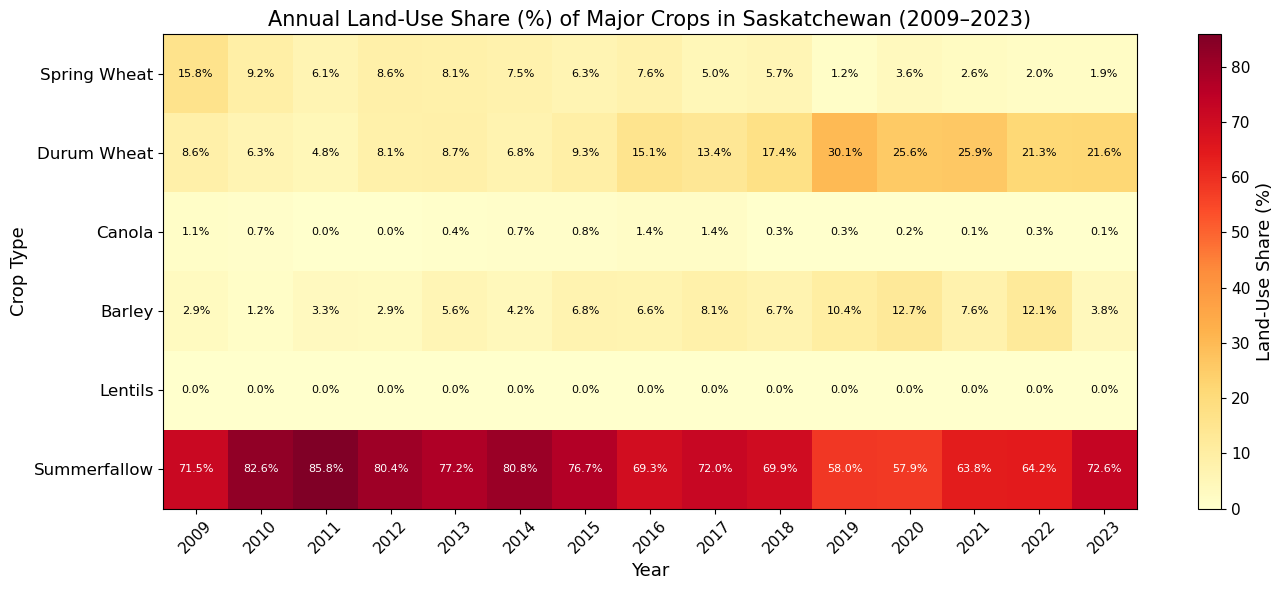

In [45]:
import matplotlib.colors as mcolors

# Build a matrix: rows = crops, columns = years
heatmap_data = df_share[list(FOCUS_CROPS.values())].T  # shape: (6 crops x 15 years)

fig, ax = plt.subplots(figsize=(14, 6))

im = ax.imshow(
    heatmap_data.values,
    aspect='auto',
    cmap='YlOrRd',
    interpolation='nearest'
)

# Axes labels
ax.set_xticks(range(len(years)))
ax.set_xticklabels(years, rotation=45, fontsize=11)
ax.set_yticks(range(len(heatmap_data.index)))
ax.set_yticklabels(heatmap_data.index, fontsize=12)

# Add value annotations inside each cell
for i in range(len(heatmap_data.index)):
    for j in range(len(years)):
        val = heatmap_data.values[i, j]
        ax.text(j, i, f'{val:.1f}%', ha='center', va='center',
                fontsize=8, color='black' if val < 50 else 'white')

# Colorbar
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Land-Use Share (%)', fontsize=13)
cbar.ax.tick_params(labelsize=11)

ax.set_title('Annual Land-Use Share (%) of Major Crops in Saskatchewan (2009–2023)', fontsize=15)
ax.set_xlabel('Year', fontsize=13)
ax.set_ylabel('Crop Type', fontsize=13)

plt.tight_layout()
plt.show()

In [ ]:
### The heatmap provides a compact, year-by-crop matrix view of land-use shares, making it easy to spot persistent patterns (e.g., wheat dominance) and gradual shifts (e.g., canola expansion) across the full 15-year period.

### Conclusion

In [1]:
This analysis examined 15 years (2009–2023) of satellite-derived crop inventory data across Saskatchewan to test whether a detectable shift from wheat toward canola has occurred.

The results provide **support for the hypothesis**: the canola-to-wheat ratio shows an overall upward trend over the study period, with canola's land-use share growing relative to both spring and durum wheat. The stacked area chart and heatmap confirm that this shift is gradual but consistent, interrupted primarily by the exceptional 2021 Prairie drought, which temporarily reduced all crop areas.

The spatial maps suggest that canola's geographic footprint has remained broadly distributed across the province, though the scatter sampling resolution (5km) limits precise conclusions about northward expansion.

**Limitations:** The analysis is based on pixel counts at 1km aggregation scale, which introduces some area estimation error. The bounding box approach includes some non-agricultural land, which may slightly dilute the crop shares. Future work could incorporate climate covariates (e.g., ERA5 temperature/precipitation anomalies) to formally test the link between climate trends and crop switching behavior.

SyntaxError: invalid character '–' (U+2013) (3229062539.py, line 1)